In [4]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
from torch.distributions import Normal
from collections import deque

# --- Hyperparameters ---
BATCH_SIZE = 256
LR_ACTOR = 3e-4
LR_CRITIC = 3e-4
GAMMA = 0.99
TAU = 0.005
ALPHA_LR = 3e-4
MEMORY_SIZE = 1_000_000
UPDATES_PER_STEP = 1
START_STEPS = 10_000 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- CUSTOM MODEL CLASSES ---

class MLPEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, ff_size):
        super(MLPEncoder, self).__init__()
        self.embedding = nn.Linear(input_size, hidden_size)
        nn.init.xavier_uniform_(self.embedding.weight)
        nn.init.zeros_(self.embedding.bias)
        self.block = nn.Sequential(
            nn.LayerNorm(hidden_size), 
            nn.Linear(hidden_size, ff_size), 
            nn.GELU(), 
            nn.Linear(ff_size, hidden_size)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.block(x)
        return x

class Critic(nn.Module):
    def __init__(self, state_dim=24, action_dim=4):
        super(Critic, self).__init__()
        self.state_encoder = MLPEncoder(state_dim, 96, 192)
        self.fc2 = nn.Linear(96 + action_dim, 192)
        nn.init.xavier_uniform_(self.fc2.weight, gain=nn.init.calculate_gain('tanh'))
        self.fc_out = nn.Linear(192, 1, bias=False)
        nn.init.uniform_(self.fc_out.weight, -0.003, +0.003)
        self.act = nn.Tanh()

    def forward(self, state, action):
        s = self.state_encoder(state)
        x = torch.cat((s, action), dim=1)
        x = self.act(self.fc2(x))
        return self.fc_out(x) * 10

class Actor(nn.Module):
    def __init__(self, state_dim=24, action_dim=4, stochastic=True):
        super(Actor, self).__init__()
        self.stochastic = stochastic
        self.state_encoder = MLPEncoder(state_dim, 96, 192)
        self.fc = nn.Linear(96, action_dim, bias=False)
        nn.init.uniform_(self.fc.weight, -0.003, +0.003)

        if self.stochastic:
            self.log_std = nn.Linear(96, action_dim, bias=False)
            nn.init.uniform_(self.log_std.weight, -0.003, +0.003)
        self.tanh = nn.Tanh()

    def forward(self, state, explore=True):
        s = self.state_encoder(state)
        if self.stochastic:
            means = self.fc(s)
            log_stds = torch.clamp(self.log_std(s), min=-20.0, max=2.0)
            stds = log_stds.exp()
            dists = Normal(means, stds)
            x = dists.rsample() if explore else means
            actions = self.tanh(x)
            log_probs = dists.log_prob(x) - torch.log(1 - actions.pow(2) + 1e-6)
            entropies = -log_probs.sum(dim=1, keepdim=True)
            return actions, entropies
        return self.tanh(self.fc(s))

# --- REPLAY BUFFER ---

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done
    
    def __len__(self):
        return len(self.buffer)

# --- AGENT LOGIC (SAC) ---

class SACAgent:
    def __init__(self, state_dim, action_dim):
        self.actor = Actor(state_dim, action_dim).to(device)
        self.actor_opt = optim.Adam(self.actor.parameters(), lr=LR_ACTOR)
        self.critic1 = Critic(state_dim, action_dim).to(device)
        self.critic2 = Critic(state_dim, action_dim).to(device)
        self.critic1_target = Critic(state_dim, action_dim).to(device)
        self.critic2_target = Critic(state_dim, action_dim).to(device)
        self.critic1_target.load_state_dict(self.critic1.state_dict())
        self.critic2_target.load_state_dict(self.critic2.state_dict())
        self.critic_opt = optim.Adam(list(self.critic1.parameters()) + list(self.critic2.parameters()), lr=LR_CRITIC)
        
        self.target_entropy = -float(action_dim)
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha_opt = optim.Adam([self.log_alpha], lr=ALPHA_LR)
        self.memory = ReplayBuffer(MEMORY_SIZE)

    def select_action(self, state, evaluate=False):
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            action, _ = self.actor(state, explore=not evaluate)
        return action.cpu().numpy()[0]

    def update(self):
        if len(self.memory) < BATCH_SIZE: return
        s, a, r, ns, d = self.memory.sample(BATCH_SIZE)
        
        s, a, ns = torch.FloatTensor(s).to(device), torch.FloatTensor(a).to(device), torch.FloatTensor(ns).to(device)
        r, d = torch.FloatTensor(r).unsqueeze(1).to(device), torch.FloatTensor(d).unsqueeze(1).to(device)

        with torch.no_grad():
            alpha = self.log_alpha.exp()
            next_a, next_ent = self.actor(ns)
            q_next = torch.min(self.critic1_target(ns, next_a), self.critic2_target(ns, next_a)) + alpha * next_ent
            target_q = r + (1 - d) * GAMMA * q_next

        # Critic Update
        self.critic_opt.zero_grad()
        (F.mse_loss(self.critic1(s, a), target_q) + F.mse_loss(self.critic2(s, a), target_q)).backward()
        self.critic_opt.step()

        # Actor Update
        pi, ent = self.actor(s)
        q_pi = torch.min(self.critic1(s, pi), self.critic2(s, pi))
        self.actor_opt.zero_grad()
        actor_loss = -(q_pi + alpha * ent).mean()
        actor_loss.backward()
        self.actor_opt.step()

        # Alpha Update
        self.alpha_opt.zero_grad()
        (-(self.log_alpha * (ent + self.target_entropy).detach()).mean()).backward()
        self.alpha_opt.step()

        # Soft Update
        for t, p in zip(self.critic1_target.parameters(), self.critic1.parameters()): t.data.copy_(t.data * (1-TAU) + p.data * TAU)
        for t, p in zip(self.critic2_target.parameters(), self.critic2.parameters()): t.data.copy_(t.data * (1-TAU) + p.data * TAU)

# --- TRAINING LOOP ---

env = gym.make("BipedalWalkerHardcore-v3")
agent = SACAgent(24, 4)
scores_window = deque(maxlen=100)
total_steps = 0

for ep in range(1, 1001):
    state, _ = env.reset() # Gymnasium reset returns (obs, info)
    ep_reward = 0
    
    while True:
        if total_steps < START_STEPS:
            action = env.action_space.sample()
        else:
            action = agent.select_action(state)
        
        # Gymnasium step returns 5 values
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        agent.memory.push(state, action, reward, next_state, terminated) # Use terminated for value bootstrapping
        
        if total_steps >= START_STEPS:
            agent.update()
            
        state = next_state
        ep_reward += reward
        total_steps += 1
        if done: break
            
    scores_window.append(ep_reward)
    if ep % 10 == 0:
        print(f"Episode {ep} | Avg Reward: {np.mean(scores_window):.2f} | Total Steps: {total_steps}")

    if np.mean(scores_window) >= 300:
        print("Hardcore Mode Beaten!")
        torch.save(agent.actor.state_dict(), "hardcore_solved.pth")
        break

Episode 10 | Avg Reward: -104.87 | Total Steps: 12369
Episode 20 | Avg Reward: -106.89 | Total Steps: 18854
Episode 30 | Avg Reward: -116.46 | Total Steps: 29472
Episode 40 | Avg Reward: -127.19 | Total Steps: 42456
Episode 50 | Avg Reward: -139.06 | Total Steps: 52597
Episode 60 | Avg Reward: -146.58 | Total Steps: 68754
Episode 70 | Avg Reward: -147.91 | Total Steps: 76398
Episode 80 | Avg Reward: -155.32 | Total Steps: 94498
Episode 90 | Avg Reward: -156.72 | Total Steps: 105993
Episode 100 | Avg Reward: -160.82 | Total Steps: 125580
Episode 110 | Avg Reward: -169.67 | Total Steps: 145580
Episode 120 | Avg Reward: -177.37 | Total Steps: 163663
Episode 130 | Avg Reward: -182.25 | Total Steps: 183663
Episode 140 | Avg Reward: -185.89 | Total Steps: 203663
Episode 150 | Avg Reward: -187.97 | Total Steps: 223663
Episode 160 | Avg Reward: -190.71 | Total Steps: 243663
Episode 170 | Avg Reward: -196.18 | Total Steps: 263638
Episode 180 | Avg Reward: -195.25 | Total Steps: 283638
Episode 1

No model found at hardcore_solved.pth. Using current agent parameters.


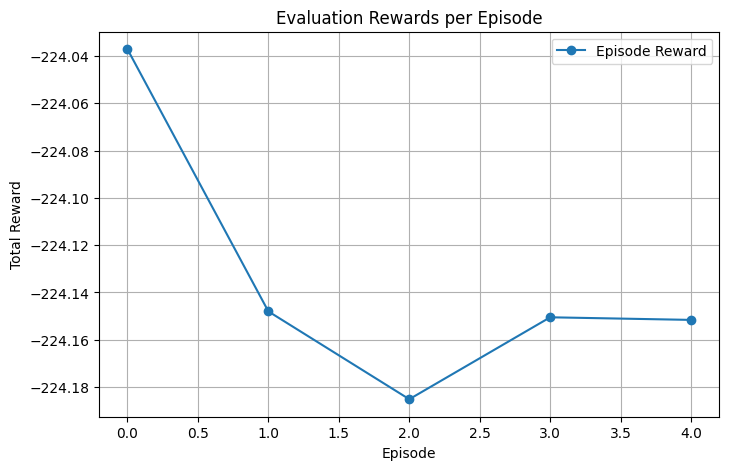

Saved evaluation GIF to bipedalwalker_eval.gif


In [7]:
# --- EVALUATION & PLOTTING ---
import matplotlib.pyplot as plt
import imageio
import os

model_path = "hardcore_solved.pth"
if os.path.exists(model_path):
    agent.actor.load_state_dict(torch.load(model_path, map_location=device))
    agent.actor.eval()
    print("Loaded saved model!")
else:
    print(f"No model found at {model_path}. Using current agent parameters.")

agent.actor.eval()

# --- Evaluation & GIF Recording ---
eval_env = gym.make("BipedalWalkerHardcore-v3", render_mode="rgb_array")
eval_env.reset(seed=42)

frames = []
eval_rewards = []

for ep in range(5):
    state, _ = eval_env.reset(seed=ep)
    done = False
    total_reward = 0
    while not done:
        action = agent.select_action(state, evaluate=True)
        next_state, reward, terminated, truncated, _ = eval_env.step(action)
        done = terminated or truncated
        total_reward += reward
        
        # Get frame from render (no mode argument!)
        frame = eval_env.render()
        frames.append(frame)
        
        state = next_state
    eval_rewards.append(total_reward)

eval_env.close()

# --- Plot Evaluation Rewards ---
plt.figure(figsize=(8,5))
plt.plot(eval_rewards, marker='o', label="Episode Reward")
plt.title("Evaluation Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()
plt.show()

# --- Save GIF ---
gif_path = "bipedalwalker_eval.gif"
imageio.mimsave(gif_path, frames, fps=30)
print(f"Saved evaluation GIF to {gif_path}")


In [ ]:
#THERE ARE MISTAKES IN HERE FIGURE OUT WHAT THEY WERE NEXT TIME
import os
import json
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

# ===============================
# CONFIG
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"
SEED = 42
N_ENVS = 8
TOTAL_TIMESTEPS = 40_000_000

LOG_DIR = "./hardcore_5/"
MODEL_DIR = os.path.join(LOG_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ===============================
# CUSTOM ARCHITECTURE
# ===============================

class MLPEncoder(BaseFeaturesExtractor):
    """
    Adapted from your original code to serve as the Feature Extractor 
    for both Actor and Critic in PPO.
    Input: Observation (24) -> Output: Embedding (96)
    """
    def __init__(self, observation_space: gym.spaces.Box, hidden_size=96, ff_size=192):
        # We assume the input is the flattened observation
        super().__init__(observation_space, features_dim=hidden_size)
        input_size = np.prod(observation_space.shape)
        
        self.embedding = nn.Linear(input_size, hidden_size)
        nn.init.xavier_uniform_(self.embedding.weight)
        nn.init.zeros_(self.embedding.bias)
        
        # Your specific block architecture
        self.block = nn.Sequential(
            nn.LayerNorm(hidden_size), 
            nn.Linear(hidden_size, ff_size), 
            nn.GELU(), 
            nn.Linear(ff_size, hidden_size)
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        x = self.embedding(observations)
        x = self.block(x)
        return x

# ===============================
# HELPERS
# ===============================

class SyncEnvStatsCallback(BaseCallback):
    def __init__(self, eval_env, sync_freq=100_000):
        super().__init__(verbose=0)
        self.eval_env = eval_env
        self.sync_freq = sync_freq

    def _on_step(self) -> bool:
        if self.n_calls % self.sync_freq == 0:
            self.eval_env.obs_rms = self.training_env.obs_rms
        return True

def make_env(rank):
    def _init():
        env = gym.make(ENV_ID)
        env.reset(seed=SEED + rank)
        return env
    return _init

def linear_schedule(initial_value: float, final_value: float = 0.0):
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value + final_value * (1 - progress_remaining)
    return func

# Note: PPO typically uses lower LR than SAC. 
# Your schedule starts at 5e-4, which is aggressive but okay for Hardcore.
l_r = linear_schedule(5e-4, 1e-5)

# ===============================
# ENVIRONMENTS
# ===============================
train_env = DummyVecEnv([make_env(i) for i in range(N_ENVS)])
train_env = VecNormalize(
    train_env,
    norm_obs=True,
    norm_reward=True,
    gamma=0.995,
    clip_obs=10.0
)

eval_env = DummyVecEnv([make_env(1000 + i) for i in range(5)])
eval_env = VecNormalize(
    eval_env,
    norm_obs=True,
    norm_reward=False,
    training=False
)

# ===============================
# CALLBACKS
# ===============================

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(MODEL_DIR, "best"),
    log_path=os.path.join(LOG_DIR, "eval"),
    eval_freq=max(100_000 // N_ENVS, 1),
    n_eval_episodes=5,
    deterministic=True,
    verbose=0,
)

sync_stats_callback = SyncEnvStatsCallback(eval_env, 100_000)

# ===============================
# MODEL
# ===============================
# Constructing the policy_kwargs to match your custom model logic
policy_kwargs = dict(
    features_extractor_class=MLPEncoder,
    features_extractor_kwargs=dict(hidden_size=96, ff_size=192),
    
    # Architecture mapping:
    # Your Original Actor: Encoder(96) -> Linear(96, Action)
    # Your Original Critic: Encoder(96) + Action -> Linear(192) -> Tanh -> Linear(1)
    
    # PPO mapping:
    # pi=[] means the Encoder output (96) connects directly to the Action head.
    # vf=[192] means Encoder output (96) goes to a hidden layer (192), then to Value head.
    net_arch=dict(pi=[], vf=[192]), 
    
    activation_fn=torch.nn.Tanh, # Used Tanh in your heads
    ortho_init=True,
    
    # Note: State Dependent Exploration (SDE) is ON as per your request
    log_std_init=-2, 
)

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    device=DEVICE,
    seed=SEED,

    # Inject Custom Architecture
    policy_kwargs=policy_kwargs,

    # PPO core
    learning_rate=l_r,
    n_steps=2048,
    batch_size=1024,
    n_epochs=8,
    gamma=0.995,    
    gae_lambda=0.95,

    # Stability fixes
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    target_kl=0.02,
    use_sde=True,
    sde_sample_freq=8, 

    verbose=1,
)

# ===============================
# TRAIN
# ===============================
print("Starting training on BipedalWalkerHardcore-v3...")
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[sync_stats_callback, eval_callback],
    progress_bar=True,
)

# ===============================
# SAVE FINAL
# ===============================
model.save(os.path.join(MODEL_DIR, "final_model"))
train_env.save(os.path.join(MODEL_DIR, "vec_normalize.pkl"))

metadata = {
    "env": ENV_ID,
    "total_timesteps": TOTAL_TIMESTEPS,
    "seed": SEED,
    "n_envs": N_ENVS,
    "device": DEVICE,
    "architecture": "Custom MLPEncoder + PPO"
}

with open(os.path.join(LOG_DIR, "run_info.json"), "w") as f:
    json.dump(metadata, f, indent=2)

train_env.close()
eval_env.close()

print("✅ Training complete.")

Using device: cpu
Using cpu device


Output()

Starting training on BipedalWalkerHardcore-v3...


------------------------------
| time/              |       |
|    fps             | 1743  |
|    iterations      | 1     |
|    time_elapsed    | 9     |
|    total_timesteps | 16384 |
------------------------------


Early stopping at step 0 due to reaching max kl: 0.03

...

-----------------------------------------
| time/                   |             |
|    fps                  | 1458        |
|    iterations           | 85          |
|    time_elapsed         | 954         |
|    total_timesteps      | 1392640     |
| train/                  |             |
|    approx_kl            | 0.024807306 |
|    clip_fraction        | 0.229       |
|    clip_range           | 0.2         |
|    entropy_loss         | -9.19       |
|    explained_variance   | 0.903       |
|    learning_rate        | 0.000483    |
|    loss                 | -0.0536     |
|    n_updates            | 257         |
|    policy_gradient_loss | -0.0165     |
|    std                  | 0.0922      |
|    value_loss           | 0.18        |
-----------------------------------------


Early stopping at step 2 due to reaching max kl: 0.03

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 2e+03       |
|    mean_reward          | -151        |
| time/                   |             |
|    total_timesteps      | 1400000     |
| train/                  |             |
|    approx_kl            | 0.026150834 |
|    clip_fraction        | 0.254       |
|    clip_range           | 0.2         |
|    entropy_loss         | -9.29       |
|    explained_variance   | 0.954       |
|    learning_rate        | 0.000483    |
|    loss                 | -0.102      |
|    n_updates            | 260         |
|    policy_gradient_loss | -0.0209     |
|    std                  | 0.0921      |
|    value_loss           | 0.0897      |
-----------------------------------------


--------------------------------
| time/              |         |
|    fps             | 1455    |
|    iterations      | 86      |
|    time_elapsed    | 968     |
|    total_timesteps | 1409024 |
--------------------------------


Early stopping at step 0 due to reaching max kl: 0.03

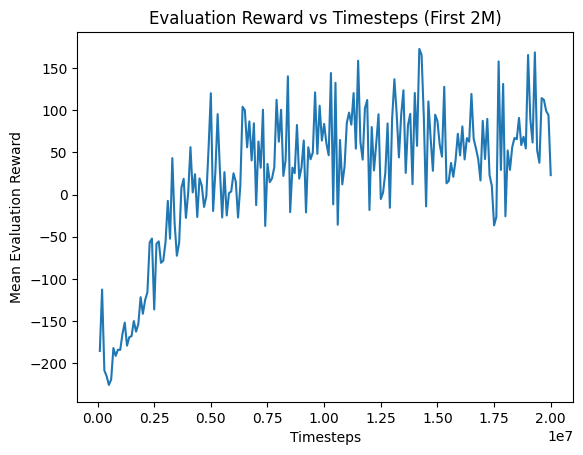

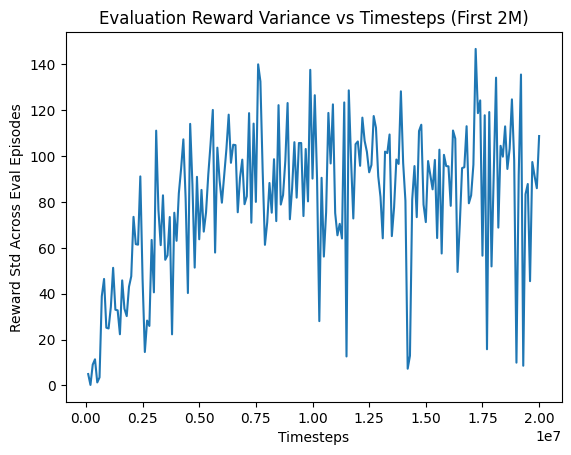

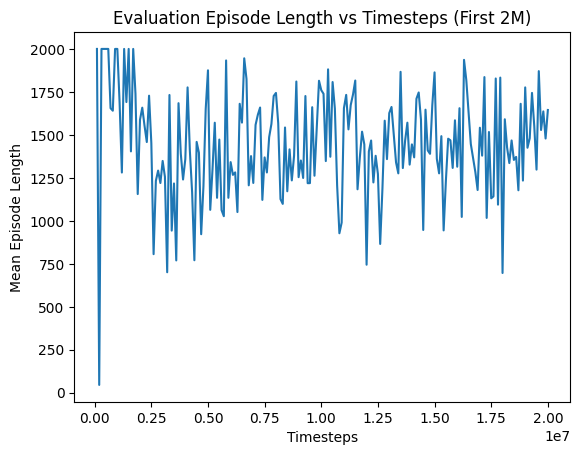

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

LOG_DIR = "./hardcore_5/"
EVAL_DIR = os.path.join(LOG_DIR, "eval")
EVAL_FILE = os.path.join(EVAL_DIR, "evaluations.npz")

assert os.path.exists(EVAL_FILE), "evaluations.npz not found. Make sure EvalCallback ran."

data = np.load(EVAL_FILE)

timesteps = data["timesteps"]
results = data["results"]          # shape: (n_evals, n_episodes)
ep_lengths = data["ep_lengths"]    # shape: (n_evals, n_episodes)


mean_rewards = results.mean(axis=1)
std_rewards = results.std(axis=1)
mean_lengths = ep_lengths.mean(axis=1)

# ===== Plot 1: Mean Eval Reward =====
plt.figure()
plt.plot(timesteps, mean_rewards)
plt.xlabel("Timesteps")
plt.ylabel("Mean Evaluation Reward")
plt.title("Evaluation Reward vs Timesteps")
plt.show()

# ===== Plot 2: Reward Std (Stability) =====
plt.figure()
plt.plot(timesteps, std_rewards)
plt.xlabel("Timesteps")
plt.ylabel("Reward Std Across Eval Episodes")
plt.title("Evaluation Reward Variance vs Timesteps (First 2M)")
plt.show()

# ===== Plot 3: Episode Length =====
plt.figure()
plt.plot(timesteps, mean_lengths)
plt.xlabel("Timesteps")
plt.ylabel("Mean Episode Length")
plt.title("Evaluation Episode Length vs Timesteps (First 2M)")
plt.show()
